In [1]:
import pandas as pd

ads = pd.read_csv("../Data/Social_Network_Ads.csv")

ads.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [2]:
from sklearn.model_selection import train_test_split

X = pd.get_dummies(ads[["Gender", "Age","EstimatedSalary"]], drop_first=True)
y = ads["Purchased"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2023)

In [3]:
from sklearn.preprocessing import StandardScaler

std = StandardScaler()

X_train_std = std.fit_transform(X_train)
X_test_std = std.transform(X_test)

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Create Models
dt = DecisionTreeClassifier(max_depth=2, min_samples_split=2) 
lr = LogisticRegression(C=3, penalty="l1", solver="saga")
knn = KNeighborsClassifier(n_neighbors=5)

# Fit Models
dt.fit(X_train_std, y_train)
lr.fit(X_train_std, y_train)
knn.fit(X_train_std, y_train)

KNeighborsClassifier()

In [5]:
from sklearn.ensemble import VotingClassifier

lr = LogisticRegression(C=3, penalty="l1", solver="saga")
dt = DecisionTreeClassifier(max_depth=2, min_samples_split=2)
knn = KNeighborsClassifier(n_neighbors=5)

model = VotingClassifier(estimators=[
    ('lr', lr), 
    ('dt', dt),
    ('knn', knn)], 
    voting='hard'
)

model.fit(X_train_std, y_train)
model.score(X_test_std,y_test)

0.8625

In [6]:
from sklearn.ensemble import VotingClassifier

lr = LogisticRegression(C=3, penalty="l1", solver="saga")
dt = DecisionTreeClassifier(max_depth=2, min_samples_split=2)
knn = KNeighborsClassifier(n_neighbors=5)

model = VotingClassifier(estimators=[
    ('lr', lr), 
    ('dt', dt),
    ('knn', knn)], 
    voting='soft'
)

model.fit(X_train_std, y_train)
model.score(X_test_std,y_test)

0.875

In [7]:
model.predict_proba(X_test_std)

array([[0.10224603, 0.89775397],
       [0.19588264, 0.80411736],
       [0.90696059, 0.09303941],
       [0.98380459, 0.01619541],
       [0.0328011 , 0.9671989 ],
       [0.09316669, 0.90683331],
       [0.98740728, 0.01259272],
       [0.11466196, 0.88533804],
       [0.9863499 , 0.0136501 ],
       [0.22446066, 0.77553934],
       [0.76064226, 0.23935774],
       [0.81705186, 0.18294814],
       [0.97767558, 0.02232442],
       [0.21520272, 0.78479728],
       [0.98531497, 0.01468503],
       [0.17039335, 0.82960665],
       [0.06948394, 0.93051606],
       [0.04290065, 0.95709935],
       [0.03633371, 0.96366629],
       [0.81484373, 0.18515627],
       [0.15611451, 0.84388549],
       [0.98550705, 0.01449295],
       [0.96946036, 0.03053964],
       [0.1862373 , 0.8137627 ],
       [0.87545881, 0.12454119],
       [0.30446887, 0.69553113],
       [0.75104519, 0.24895481],
       [0.03263878, 0.96736122],
       [0.10537341, 0.89462659],
       [0.96089625, 0.03910375],
       [0.

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Create Models
dt = DecisionTreeClassifier(max_depth=2, min_samples_split=2) 
lr = LogisticRegression(C=3, penalty="l1", solver="saga")
knn = KNeighborsClassifier(n_neighbors=5)

model = VotingClassifier(estimators=[
    ('lr', lr), 
    ('dt', dt),
    ('knn', knn)], 
    voting='soft'
)

model.fit(X_train_std, y_train)
model.score(X_test_std,y_test)

0.875

In [9]:
knn = knn.fit(X_train_std, y_train)


In [10]:
model.predict_proba(X_test_std)[:5]

array([[0.102122  , 0.897878  ],
       [0.19587177, 0.80412823],
       [0.90688263, 0.09311737],
       [0.98380501, 0.01619499],
       [0.03279764, 0.96720236]])

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=2023)

rf.fit(X_train, y_train)

print(f"Training Accuracy: {rf.score(X_train, y_train)}")
print(f"Test Accuracy: {rf.score(X_test, y_test)}")

Training Accuracy: 0.996875
Test Accuracy: 0.8375


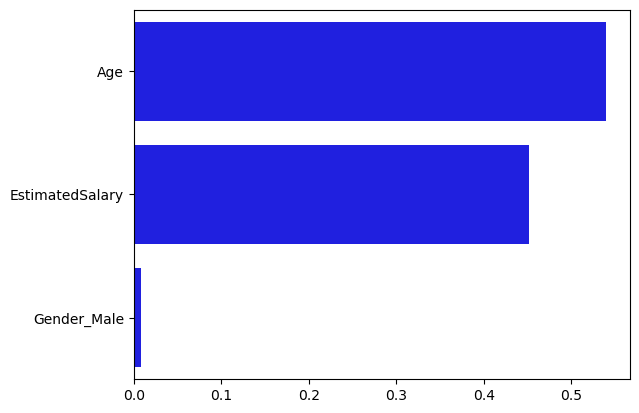

In [12]:
import seaborn as sns

sns.barplot(x=rf.feature_importances_, y=X.columns, color="blue");

In [13]:
rf.feature_importances_

array([0.53978492, 0.45165151, 0.00856358])

In [14]:
import numpy as np
np.arange(start=100, stop=1100, step=100)

array([ 100,  200,  300,  400,  500,  600,  700,  800,  900, 1000])

In [15]:
import numpy as np
from sklearn.model_selection import GridSearchCV



rf = RandomForestClassifier(random_state=2023, n_jobs=-1)

params = {
    'n_estimators': np.arange(start=100, stop=1100, step=100),
    'max_features': [None, "sqrt"],
    'bootstrap': [True, False],
    'max_samples': [None, .3, .5, .9],
    'max_depth': np.arange(start=1, stop=11, step=1),
    'min_samples_leaf': [2, 5, 10, 20, 100]    
}

grid = GridSearchCV(rf, params)

grid.fit(X_train, y_train)

grid.best_params_

KeyboardInterrupt: 

Šitas gridas yra labai didelis, todėl ir sukasi labai ilgai.

Problema yra parametrų kombinacijų skaičius :

n_estimators: 10

max_features: 2

bootstrap: 2

max_samples: 4

max_depth: 10

min_samples_leaf: 5

Iš viso: 10 × 2 × 2 × 4 × 10 × 5 = 8000 kombinacijų

O GridSearchCV pagal nutylėjimą daro 5-fold CV, tai realiai treniruojama apie:

8000 × 5 = 40 000 modelių

Random Forest pats savaime nėra lengvas modelis, todėl čia labai brangu ir reikia optimizuoti

In [16]:
rf = RandomForestClassifier(random_state=2023, n_jobs=-1)

params = {
    'n_estimators': [100, 300, 500],
    'max_features': ["sqrt"],
    'bootstrap': [True],
    'max_samples': [0.5, 0.7, 0.9],
    'max_depth': [None, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

grid = GridSearchCV(
    rf,
    params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

Fitting 3 folds for each of 81 candidates, totalling 243 fits
{'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'max_samples': 0.5, 'min_samples_leaf': 2, 'n_estimators': 100}


Optimizuotas variantas vietoj 8000 kombinacijų tikrina tik 30. Krosvalidacija susiaurinta iki cv=3 tai bus tik apie 90 modelių, o ne 40 000.

In [24]:
rf = RandomForestClassifier(
    random_state=2023,
    n_estimators=100,
    max_features="sqrt",
    bootstrap=True,
    max_samples=0.5,
    max_depth=4,
    min_samples_leaf=2
)

rf.fit(X_train, y_train)

print(f"Training Accuracy: {rf.score(X_train, y_train)}")
print(f"Test Accuracy: {rf.score(X_test, y_test)}")

Training Accuracy: 0.93125
Test Accuracy: 0.875


In [25]:
rf.feature_importances_

array([0.56204678, 0.42843201, 0.00952121])

<Axes: >

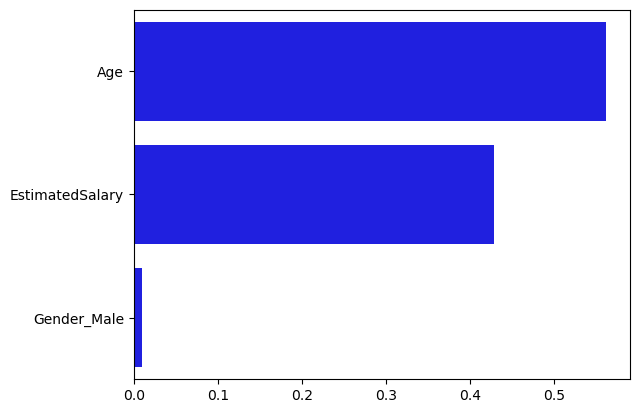

In [26]:
sns.barplot(x=rf.feature_importances_, y=X.columns, color="blue")

In [21]:
from sklearn.model_selection import RandomizedSearchCV
      
rf = RandomForestClassifier(random_state=2023)

params = {
    'n_estimators': np.arange(start=100, stop=1100, step=100),
    'max_features': [None, "sqrt"],
    'bootstrap': [True, False],
    'max_samples': [None, .3, .5, .9],
    'max_depth': np.arange(start=1, stop=11, step=1),
    'min_samples_leaf': [2, 5, 10, 20, 100]    
}

grid = RandomizedSearchCV(
    rf, 
    params,
    n_iter=100,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

grid.best_params_

KeyboardInterrupt: 

In [22]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(
    random_state=2023,
    n_jobs=-1
)

params = {
    'n_estimators': [100, 200, 300, 500, 700],
    'max_features': [None, "sqrt"],
    'bootstrap': [True],
    'max_samples': [0.3, 0.5, 0.9],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_leaf': [1, 2, 5, 10, 20]
}

grid = RandomizedSearchCV(
    estimator=rf,
    param_distributions=params,
    n_iter=30,
    scoring="accuracy",
    cv=3,
    random_state=2023,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
{'n_estimators': 100, 'min_samples_leaf': 10, 'max_samples': 0.5, 'max_features': None, 'max_depth': 3, 'bootstrap': True}


In [27]:
from sklearn.model_selection import RandomizedSearchCV
      
rf = RandomForestClassifier(random_state=2023)

params = {
    'n_estimators': np.arange(start=100, stop=1100, step=100),
    'max_features': [None, "sqrt"],
    'bootstrap': [True, False],
    'max_samples': [None, .3, .5, .9],
    'max_depth': np.arange(start=1, stop=11, step=1),
    'min_samples_leaf': [2, 5, 10, 20, 100]    
}

grid = RandomizedSearchCV(
    rf, 
    params,
    n_iter=100,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

grid.best_params_

KeyboardInterrupt: 

In [28]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(
    random_state=2023,
    n_jobs=-1
)

params = {
    'n_estimators': [100, 200, 300, 500, 700],
    'max_features': ["sqrt"],
    'bootstrap': [True],
    'max_samples': [0.5, 0.7, 0.9],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_leaf': [1, 2, 5, 10]
}

grid = RandomizedSearchCV(
    rf,
    param_distributions=params,
    n_iter=30,
    cv=3,
    scoring="accuracy",
    random_state=2023,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
{'n_estimators': 100, 'min_samples_leaf': 2, 'max_samples': 0.5, 'max_features': 'sqrt', 'max_depth': 7, 'bootstrap': True}


In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    min_samples_leaf=2,
    max_samples=0.5,
    max_features="sqrt",
    max_depth=7,
    bootstrap=True,
    random_state=2023,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=7, max_samples=0.5, min_samples_leaf=2,
                       n_jobs=-1, random_state=2023)

In [29]:
!conda install shap --y

Retrieving notices: ...working... done
Solving environment: ...working... done

# All requested packages already installed.


c:\Users\User\OneDrive\Desktop\BIT\2025 11 12 DUOM\V Modulis_Python_2025 11 12 DUOM\BIT_PYTHON\Python_Classification\Slides and Demos>set CMDSTAN= 

c:\Users\User\OneDrive\Desktop\BIT\2025 11 12 DUOM\V Modulis_Python_2025 11 12 DUOM\BIT_PYTHON\Python_Classification\Slides and Demos>set CMDSTAN_OLD= 

c:\Users\User\OneDrive\Desktop\BIT\2025 11 12 DUOM\V Modulis_Python_2025 11 12 DUOM\BIT_PYTHON\Python_Classification\Slides and Demos>SET CMDSTAN_OLD= 

c:\Users\User\OneDrive\Desktop\BIT\2025 11 12 DUOM\V Modulis_Python_2025 11 12 DUOM\BIT_PYTHON\Python_Classification\Slides and Demos>SET CMDSTAN=C:/Users/User/anaconda3\Library\bin\cmdstan\ 


DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): repo.anaconda.com:443
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): repo.anaconda.com:443
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): repo.anaconda.com:443
DEBUG:urllib3.connectionpool:https://repo.anaconda.com:443 "GET /pkgs/main/notices.json HTTP/1.1" 404 None
DEBUG:urllib3.connectionpool:https://repo.anaconda.com:443 "GET /pkgs/r/notices.json HTTP/1.1" 404 None
DEBUG:urllib3.connectionpool:https://repo.anaconda.com:443 "GET /pkgs/msys2/notices.json HTTP/1.1" 404 None
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): repo.anaconda.com:443
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): repo.anaconda.com:443
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): repo.anaconda.com:443
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): repo.anaconda.com:443
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): repo.anaconda.c

In [35]:
X_test.dtypes

Age                int64
EstimatedSalary    int64
Gender_Male         bool
dtype: object

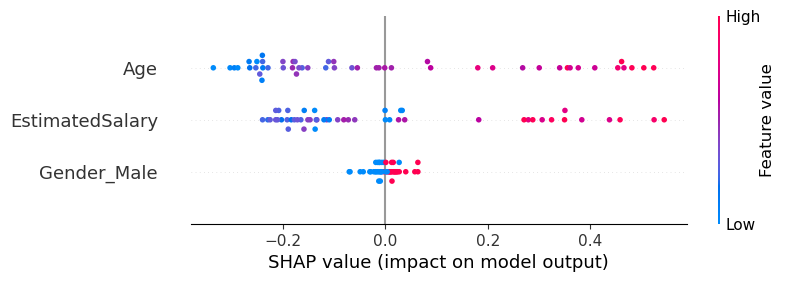

In [37]:
import shap

explainer = shap.Explainer(rf, X_test.sample(50, random_state=12345).astype(int))

shap_values = explainer(X_test.sample(50, random_state=12345))

shap.plots.beeswarm(shap_values[:,:,1])

In [39]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=2023,
    n_estimators=100,
    learning_rate=0.01,
    max_features="sqrt",
    subsample=1.0,
    max_depth=3,
    min_samples_leaf=1
)

gb.fit(X_train, y_train)

print(f"Training Accuracy: {gb.score(X_train, y_train)}")
print(f"Test Accuracy: {gb.score(X_test, y_test)}")

Training Accuracy: 0.934375
Test Accuracy: 0.875


In [41]:
import numpy as np

from sklearn.model_selection import RandomizedSearchCV
      
gb = GradientBoostingClassifier(random_state=2023)

params = {
    'n_estimators': np.arange(start=100, stop=1100, step=100),
    'learning_rate': [.001, .01, .1, .2],
    'max_features': [None, "sqrt"],
    'subsample': [.8, .9, 1.0],
    'max_depth': np.arange(start=3, stop=12, step=2),
    'min_samples_leaf': [2, 5, 10]    
}

grid = RandomizedSearchCV(
    gb, 
    params,
    n_iter=100,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

grid.best_params_

KeyboardInterrupt: 

paieškos erdvė yra:

n_estimators = 10

learning_rate = 4

max_features = 2

subsample = 3

max_depth = 5

min_samples_leaf = 3

Iš viso: 10 × 4 × 2 × 3 × 5 × 3 = 3600 kombinacijų

Su RandomizedSearchCV(n_iter=100) ir numatytu cv=5 gaunasi apie:

100 × 5 = 500 fitų

In [42]:
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

gb = GradientBoostingClassifier(random_state=2023)

params = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_features': [None, "sqrt"],
    'subsample': [0.8, 1.0],
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [1, 2, 5]
}

grid = RandomizedSearchCV(
    gb,
    param_distributions=params,
    n_iter=30,
    cv=3,
    scoring="accuracy",
    random_state=2023,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
{'subsample': 0.8, 'n_estimators': 300, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 3, 'learning_rate': 0.01}


In [43]:
import numpy as np

from sklearn.model_selection import GridSearchCV
      
gb = GradientBoostingClassifier(random_state=2023)

params = {
    'n_estimators': np.arange(start=350, stop=450, step=10),
    'learning_rate': [.005, .01, .015, .25],
    'max_features': [None, "sqrt"],
    'subsample': [.9, .95, 1.0],
    'max_depth': [2, 3, 4],
    'min_samples_leaf': [1, 2, 3]    
}

grid = GridSearchCV(
    gb, 
    params,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

grid.best_params_

KeyboardInterrupt: 

n_estimators: 10

learning_rate: 4

max_features: 2

subsample: 3

max_depth: 3

min_samples_leaf: 3

Iš viso:

10 × 4 × 2 × 3 × 3 × 3 = 2160 kombinacijų

Kadangi GridSearchCV tikrina visas kombinacijas, o pagal nutylėjimą daro 5-fold CV, bus:

2160 × 5 = 10 800 fitų


In [44]:
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

gb = GradientBoostingClassifier(random_state=2023)

params = {
    'n_estimators': [350, 380, 410, 440],
    'learning_rate': [0.005, 0.01, 0.015],
    'max_features': ["sqrt"],
    'subsample': [0.9, 1.0],
    'max_depth': [2, 3, 4],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    gb,
    param_grid=params,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

Fitting 3 folds for each of 144 candidates, totalling 432 fits
{'learning_rate': 0.005, 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 350, 'subsample': 0.9}


4 × 3 × 1 × 2 × 3 × 2 = 144

su cv=3 -> 432 fitai

In [ ]:
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

gb = GradientBoostingClassifier(random_state=2023)

params = {
    'n_estimators': [350, 380, 410, 440],
    'learning_rate': [0.005, 0.01, 0.015],
    'max_features': ["sqrt"],
    'subsample': [0.9, 1.0],
    'max_depth': [2, 3, 4],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    gb,
    param_grid=params,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

In [45]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    **grid.best_params_,
    random_state=2023
)

gb.fit(X_train, y_train)

print(f"Training Accuracy: {gb.score(X_train, y_train)}")
print(f"Test Accuracy: {gb.score(X_test, y_test)}")

Training Accuracy: 0.9375
Test Accuracy: 0.8625


In [46]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    learning_rate=.01,
    max_depth=3,
    max_features=None,
    min_samples_leaf=2,
    n_estimators=350,
    subsample=.95,
    random_state=2023
)

gb.fit(X_train, y_train)

print(f"Training Accuracy: {gb.score(X_train, y_train)}")
print(f"Test Accuracy: {gb.score(X_test, y_test)}")

Training Accuracy: 0.946875
Test Accuracy: 0.85


In [47]:
X_test["Gender_Male"] = X_test["Gender_Male"].astype("int")

In [48]:
import shap

# Pass fitted model into shap's Explainer Function
explainer = shap.Explainer(gb, X_test)

# Pass in data to calculate SHAP values for - often just want a sample
shap_values = explainer(X_test.sample(80, random_state=2023))

# shap_values is an array - creating DataFrame so we can view column names
shap_df = pd.DataFrame(shap_values.values, columns=X_test.columns)

shap_df.head()

,Age,EstimatedSalary,Gender_Male
0,-1.844862,-1.168524,0.036242
1,3.339030,0.023602,-0.067178
2,2.044172,0.356212,-0.182657
3,0.040502,0.271765,-0.039079
4,-2.190638,-0.815303,0.038950


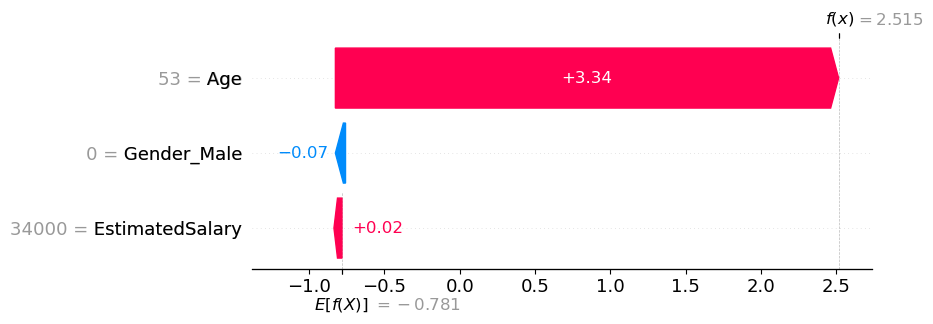

In [49]:
shap.plots.waterfall(shap_values[1])

SHAP waterfall grafikas parodo, kaip kiekvienas požymis prisideda prie galutinės modelio prognozės.

Modelio bazinė reikšmė yra E(f(X)) = -0.781, tai vidutinė modelio prognozė visiems duomenims.

Didžiausią teigiamą įtaką prognozei turi Age = 53, kuris padidina modelio reikšmę apie +3.34.

EstimatedSalary = 34000 turi labai mažą teigiamą poveikį (+0.02), todėl beveik nekeičia prognozės.

Gender_Male = 0 turi nedidelį neigiamą poveikį (-0.07), šiek tiek sumažindamas prognozę.


SHAP grafike f(x) rodo modelio išvestį log-odds (logit) skalėje. Tai yra vidinė modelio reikšmė, iš kurios vėliau apskaičiuojama tikimybė.

Tikimybė gaunama pritaikius logistinę funkciją:

p = 1 / (1 + e^(-f(x)))

Todėl kuo didesnė f(x) reikšmė, tuo didesnė tikimybė klasės 1.

Neigiama f(x) reikšmė reiškia mažesnę klasės 1 tikimybę.
Sujungus visų požymių poveikius gaunama galutinė modelio prognozė f(x) = 2.515. Didžiausią įtaką prognozei šiame pavyzdyje turi amžius.

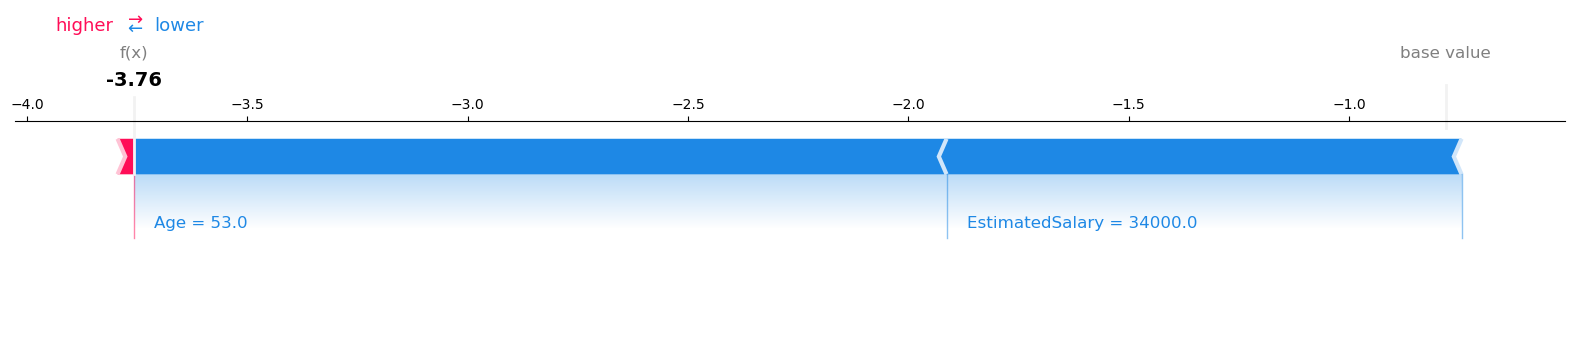

In [55]:
shap.plots.force(
    base_value=shap_values.base_values[0],
    shap_values=shap_values.values[0, :],
    features=X_test.iloc[0, :],
    matplotlib=True
)

SHAP force plot parodo, kaip kiekvienas požymis paveikė konkrečios stebėjimo prognozę.

Modelio prognozė susideda iš:
base value + visų požymių poveikių = galutinė prognozė.

Base value yra vidutinė modelio prognozė visiems duomenims. Grafike ji rodoma dešinėje pusėje.

f(x) = -3.76 yra galutinė modelio prognozės reikšmė šiai konkrečiai stebėjimo eilutei. Logistinėje klasifikacijoje ši reikšmė pateikiama log-odds skalėje.

Spalvos rodo požymių poveikį prognozei:
raudona spalva reiškia, kad požymis didina tikimybę klasės 1,
mėlyna spalva reiškia, kad požymis mažina tikimybę klasės 1.

Šiame pavyzdyje matome du svarbiausius požymius:
Age = 53 šiek tiek didina prognozę (stumia modelį link klasės 1).
EstimatedSalary = 34000 stipriai mažina prognozę (stumia modelį link klasės 0).

Todėl galutinė modelio prognozė yra labiau link klasės 0, nes mažesnė alga turi stipresnį neigiamą poveikį nei amžiaus teigiamas poveikis.

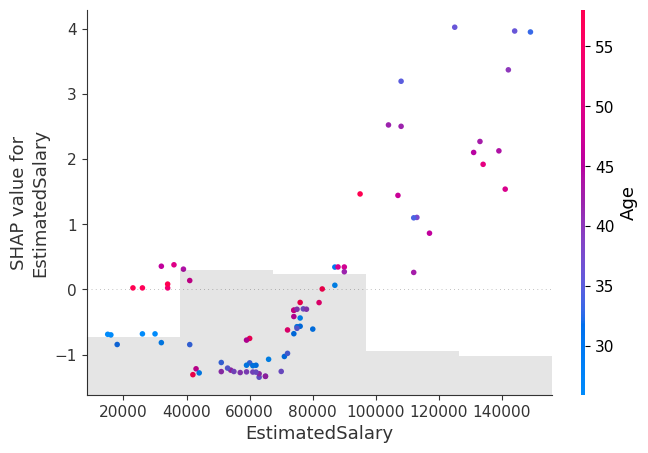

In [51]:
shap.plots.scatter(
    shap_values[:, 1], # plot salary in X
    color=shap_values[:, 0] # color by age
)

SHAP dependence grafikas rodo, kaip požymis EstimatedSalary veikia modelio prognozę.

Horizontalioje ašyje pateikiama alga (EstimatedSalary), o vertikalioje – SHAP reikšmė, kuri parodo šio požymio poveikį modelio prognozei.

Neigiamos SHAP reikšmės reiškia, kad mažesnė alga mažina tikimybę klasės 1, o teigiamos reikšmės reiškia, kad didesnė alga didina šią tikimybę.

Grafike matyti, kad esant mažesnėms algoms (apie 20 000–70 000), SHAP reikšmės dažniausiai yra neigiamos, todėl modelis linkęs prognozuoti klasę 0.

Didėjant algai (virš maždaug 90 000), SHAP reikšmės tampa teigiamos, todėl didesnė alga didina klasės 1 tikimybę.

Spalva rodo Age reikšmę, todėl galima matyti, kad vyresni asmenys (raudonesni taškai) dažniau turi didesnį teigiamą poveikį prognozei nei jaunesni.

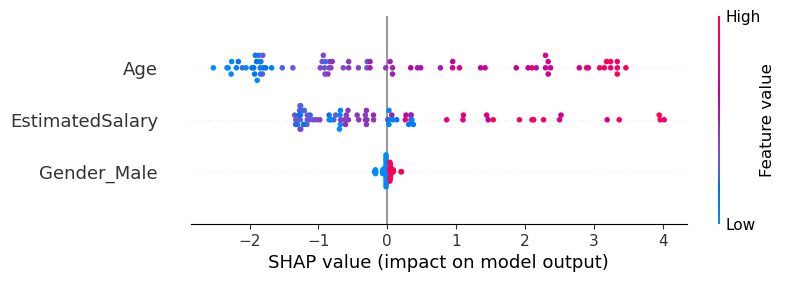

In [52]:
shap.plots.beeswarm(shap_values)

SHAP summary (beeswarm) grafikas parodo, kurie požymiai turi didžiausią įtaką modelio prognozėms ir kokia yra jų poveikio kryptis.

Kiekvienas taškas grafike atitinka vieną stebėjimą. Horizontalioje ašyje pateikiama SHAP reikšmė, kuri parodo, kiek tas požymis padidina arba sumažina modelio prognozę.

Didžiausią įtaką modelio prognozei turi Age. Didesnės amžiaus reikšmės (raudoni taškai) dažniausiai didina modelio prognozę, o mažesnės (mėlyni taškai) ją mažina.

EstimatedSalary taip pat turi reikšmingą poveikį: didesnės algos dažniausiai didina modelio prognozę, o mažesnės algos ją mažina.

Gender_Male turi labai mažą poveikį prognozei, nes dauguma taškų yra arti nulio, todėl šis požymis modelio sprendimui turi nedidelę įtaką.

Pagal SHAP reikšmių pasiskirstymą galima matyti, kad modelio sprendimuose svarbiausi yra Age ir EstimatedSalary, o Gender_Male yra mažiausiai reikšmingas požymis.